In [1]:
!pip -q install datasets scikit-learn pandas matplotlib seaborn

In [2]:
# @title Import libraries

In [3]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [4]:
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train shape: (25000, 2)
Test shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [5]:
print("Train label distribution:")
print(train_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train label distribution:
label
0    12500
1    12500
Name: count, dtype: int64

Test label distribution:
label
0    12500
1    12500
Name: count, dtype: int64


In [6]:
print("Sample negative review:\n")
print(train_df[train_df["label"] == 0]["text"].iloc[0][:1000])

print("\n" + "="*80 + "\n")

print("Sample positive review:\n")
print(train_df[train_df["label"] == 1]["text"].iloc[0][:1000])

Sample negative review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are

In [7]:
train_df["review_length_words"] = train_df["text"].apply(lambda x: len(x.split()))
test_df["review_length_words"] = test_df["text"].apply(lambda x: len(x.split()))

print(train_df["review_length_words"].describe())

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: review_length_words, dtype: float64


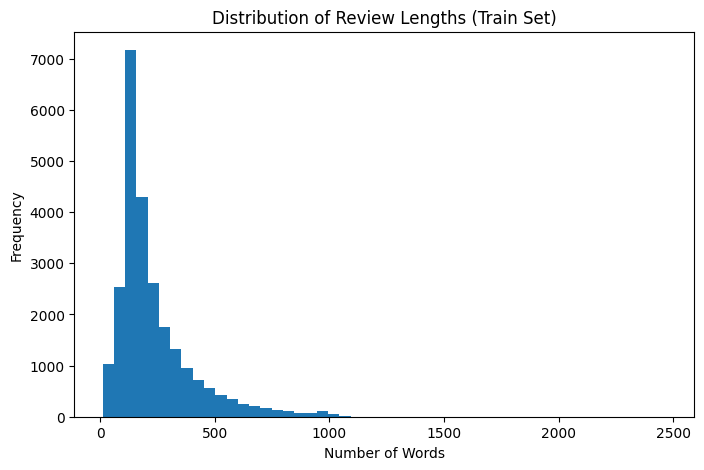

In [8]:
plt.figure(figsize=(8,5))
plt.hist(train_df["review_length_words"], bins=50)
plt.title("Distribution of Review Lengths (Train Set)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)     # remove HTML line breaks
    text = re.sub(r"[^a-z0-9\s']", " ", text)  # keep letters, digits, apostrophes
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

In [10]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text"]].head(2)

,text,clean_text
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...


In [11]:
X_train = train_df["clean_text"]
y_train = train_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(25000,) (25000,)
(25000,) (25000,)


In [12]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (25000, 20000)
TF-IDF test shape: (25000, 20000)


In [13]:
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

Training time: 0.75 seconds


In [14]:
y_pred = lr_model.predict(X_test_tfidf)

In [15]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8951
Precision: 0.8924
Recall   : 0.8986
F1-score : 0.8955


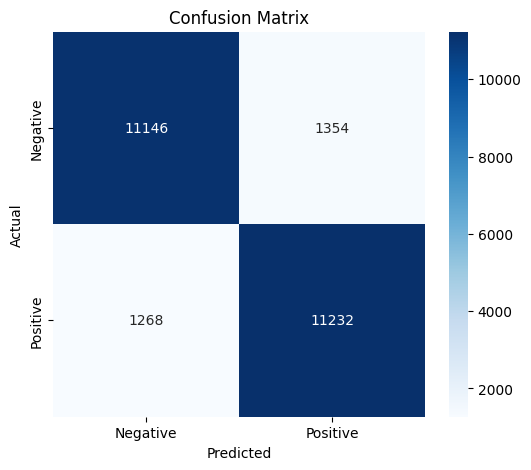

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
results_df = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "train_time_sec": train_time
    }
])

results_df

,model,accuracy,precision,recall,f1_score,train_time_sec
0,TF-IDF + Logistic Regression,0.89512,0.89242,0.89856,0.89548,0.754393


In [18]:
error_df = test_df.copy()
error_df["pred"] = y_pred
error_df["correct"] = (error_df["label"] == error_df["pred"])

errors = error_df[error_df["correct"] == False]
print("Number of misclassified reviews:", len(errors))
errors.head()

Number of misclassified reviews: 2622


,text,label,review_length_words,clean_text,pred,correct
4,"First off let me say, If you haven't enjoyed a...",0,134,first off let me say if you haven't enjoyed a ...,1,False
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,249,ben rupert grint is a deeply unhappy adolescen...,1,False
22,The Forgotten (AKA: Don't Look In The Basement...,0,126,the forgotten aka don't look in the basement i...,1,False
32,I'm the type of guy who loves hood movies from...,0,391,i'm the type of guy who loves hood movies from...,1,False
46,"Okay, so it was never going to change the worl...",0,320,okay so it was never going to change the world...,1,False


In [19]:
for i in range(3):
    row = errors.iloc[i]
    print(f"Example {i+1}")
    print("True label     :", "Positive" if row["label"] == 1 else "Negative")
    print("Predicted label:", "Positive" if row["pred"] == 1 else "Negative")
    print("Review snippet :", row["text"][:1200])
    print("\n" + "="*100 + "\n")

Example 1
True label     : Negative
Predicted label: Positive
Review snippet : First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!


Example 2
True label     : Negative
Predicted label: Positive
Review snippet : Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney

In [20]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_positive_idx = np.argsort(coefs)[-20:]
top_negative_idx = np.argsort(coefs)[:20]

top_positive_words = feature_names[top_positive_idx]
top_negative_words = feature_names[top_negative_idx]

print("Top positive words/phrases:")
print(top_positive_words)

print("\nTop negative words/phrases:")
print(top_negative_words)

Top positive words/phrases:
['highly' 'beautiful' 'bit' 'enjoyed' 'superb' 'favorite' 'brilliant'
 'well' 'love' 'and' 'loved' 'today' 'best' 'fun' 'the best' 'amazing'
 'wonderful' 'perfect' 'excellent' 'great']

Top negative words/phrases:
['bad' 'worst' 'awful' 'the worst' 'boring' 'poor' 'waste' 'terrible'
 'nothing' 'worse' 'no' 'dull' 'horrible' 'poorly' 'stupid'
 'unfortunately' 'annoying' 'ridiculous' 'script' 'disappointing']


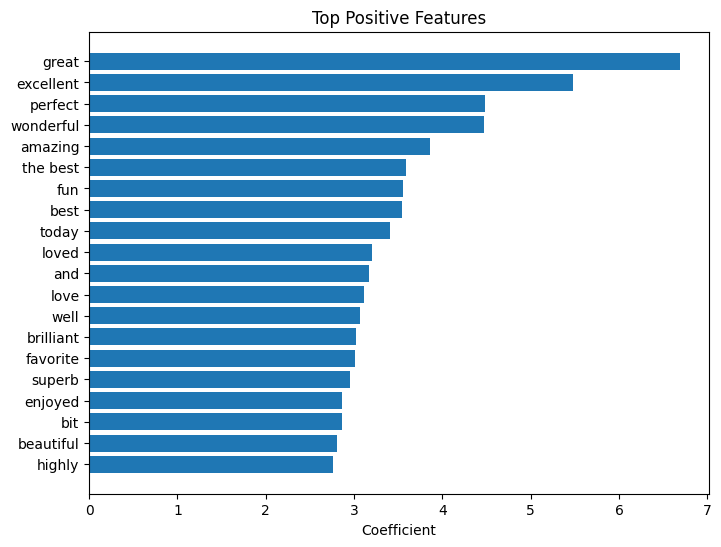

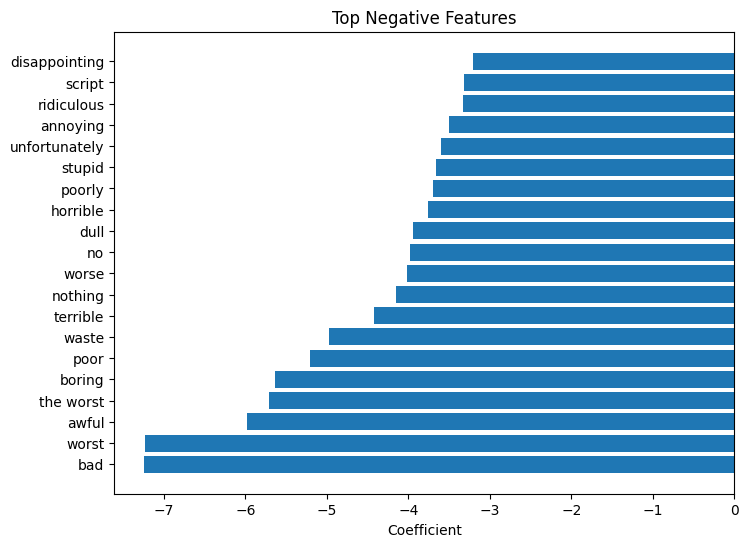

In [21]:
top_pos_df = pd.DataFrame({
    "feature": feature_names[top_positive_idx],
    "weight": coefs[top_positive_idx]
}).sort_values("weight", ascending=True)

top_neg_df = pd.DataFrame({
    "feature": feature_names[top_negative_idx],
    "weight": coefs[top_negative_idx]
}).sort_values("weight", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(top_pos_df["feature"], top_pos_df["weight"])
plt.title("Top Positive Features")
plt.xlabel("Coefficient")
plt.show()

plt.figure(figsize=(8,6))
plt.barh(top_neg_df["feature"], top_neg_df["weight"])
plt.title("Top Negative Features")
plt.xlabel("Coefficient")
plt.show()